In [1]:
import pandas as pd
import numpy as np
from scipy.optimize import linprog

MATRIX_A_URL = "https://docs.google.com/spreadsheets/d/e/2PACX-1vRfPEoORlxfObu9nOQy360G2xc3cWpTcCQbIPd9ctBuB__qgXiaviP93Xi0UnQdA9NdR8qV-ReHd_ls/pub?output=csv"

FOODS_PATH = "foods_with_fcd_id.csv"

CONSTRAINTS_CSV_BY_DISABILITY = {
    "No disability":  "https://docs.google.com/spreadsheets/d/e/2PACX-1vRwJ2PiAGGKwIdHJYBnLP7bd0uT_qHJG1tqnAEQgSerlZOgxHigFfVZTxHbURUTCtkJJkPZTcDoiQ6L/pub?output=csv&gid=0",
    "Celiac":         "https://docs.google.com/spreadsheets/d/e/2PACX-1vRwJ2PiAGGKwIdHJYBnLP7bd0uT_qHJG1tqnAEQgSerlZOgxHigFfVZTxHbURUTCtkJJkPZTcDoiQ6L/pub?output=csv&gid=761693646",
    "Diabetes":       "https://docs.google.com/spreadsheets/d/e/2PACX-1vRwJ2PiAGGKwIdHJYBnLP7bd0uT_qHJG1tqnAEQgSerlZOgxHigFfVZTxHbURUTCtkJJkPZTcDoiQ6L/pub?output=csv&gid=1282759486",
    "Kidney disease": "https://docs.google.com/spreadsheets/d/e/2PACX-1vRwJ2PiAGGKwIdHJYBnLP7bd0uT_qHJG1tqnAEQgSerlZOgxHigFfVZTxHbURUTCtkJJkPZTcDoiQ6L/pub?output=csv&gid=1065244903",
}

GRAMS_PER_EGG = 50.0
GRAMS_PER_GALLON = 3785.41

EXCLUDED_FOODS = [
    "flour",
    "white flour",
]

MAX_100G_UNITS_PER_FOOD = 20

GLUTEN_FOODS = [
    "white flour", "spaghetti", "white bread", "whole wheat bread",
    "chocolate chip cookie", "potato chip",
]

MEAT_FOODS = [
    "lean ground beef", "stew beef", "steak, round", "steak, sirloin",
    "bacon", "pork chops", "ham", "chicken legs, bone-in",
    "chicken breast, boneless", "ground chuck beef", "ground beef",
]
KIDNEY_MEAT_MAX_GRAMS = 85.0

NUTRIENT_NAME_MAP = {
    "Saturated Fat": "Fatty acids, total saturated",
}

def group_col(sex: str, age_group: str) -> str:
    return f"{sex.strip().title()}_{age_group.strip()}"

def quantity_to_grams(qty, unit) -> float:
    if pd.isna(qty) or pd.isna(unit):
        return np.nan

    q = float(qty)
    u = str(unit).strip().lower().replace(".", "")
    if u.endswith("s"):
        u = u[:-1]

    if u in ["g", "gram"]:
        return q
    if u in ["kg", "kilogram"]:
        return q * 1000.0
    if u in ["oz", "ounce"]:
        return q * 28.349523125
    if u in ["lb", "pound"]:
        return q * 453.59237
    if u in ["gallon"]:
        return q * GRAMS_PER_GALLON
    if u in ["egg"]:
        return q * GRAMS_PER_EGG

    return np.nan

def is_excluded_food(food_name: str, disability: str = "") -> bool: 
    f = str(food_name).strip().lower()
    if any(ex in f for ex in EXCLUDED_FOODS):
        return True

    if disability == "Celiac":
        if any(f == gf.lower() for gf in GLUTEN_FOODS):
            return True
    return False

def load_A() -> pd.DataFrame:
    df = pd.read_csv(MATRIX_A_URL)

    if "Food" not in df.columns:
        df = df.rename(columns={df.columns[0]: "Food"})

    df["Food"] = df["Food"].astype(str).str.strip()
    df = df.dropna(subset=["Food"]).drop_duplicates(subset=["Food"]).set_index("Food")

    df = df.apply(pd.to_numeric, errors="coerce").fillna(0.0)

    A = df.T
    A.index = A.index.astype(str).str.strip()
    A.columns = A.columns.astype(str).str.strip()

    return A


def load_p() -> pd.Series:
    foods = pd.read_csv(FOODS_PATH)
    foods.columns = [str(c).strip() for c in foods.columns]

    need = {"Food", "Price", "Quantity", "Units"}
    missing = need - set(foods.columns)
    if missing:
        raise ValueError(f"{FOODS_PATH} missing {missing}. Found: {list(foods.columns)}")

    foods["Food"] = foods["Food"].astype(str).str.strip()
    foods["Price"] = pd.to_numeric(foods["Price"], errors="coerce")
    foods["Quantity"] = pd.to_numeric(foods["Quantity"], errors="coerce")
    foods["Units"] = foods["Units"].astype(str).str.strip()

    foods["grams_in_package"] = foods.apply(
        lambda r: quantity_to_grams(r["Quantity"], r["Units"]), axis=1
    )

    foods = foods.dropna(subset=["Price", "grams_in_package"])
    foods = foods[(foods["grams_in_package"] > 0) & (foods["Price"] > 0)]

    foods["price_per_100g"] = foods["Price"] / (foods["grams_in_package"] / 100.0)

    p = foods.set_index("Food")["price_per_100g"]
    p = pd.to_numeric(p, errors="coerce").dropna()
    p = p[np.isfinite(p) & (p > 0)]
    p = p[~p.index.duplicated(keep="first")]

    return p

def load_constraints(disability: str, group: str) -> tuple[pd.Series, pd.Series]:
    df = pd.read_csv(CONSTRAINTS_CSV_BY_DISABILITY[disability])
    df.columns = [str(c).strip() for c in df.columns]

    for col in ["Nutrient", "Constraint Type"]:
        if col not in df.columns:
            raise ValueError(f"Constraints CSV missing '{col}'. Found: {list(df.columns)}")

    if group not in df.columns:
        raise ValueError(f"Group '{group}' not found in constraints. Available: {list(df.columns)}")

    df["Nutrient"] = df["Nutrient"].astype(str).str.strip()
    df["Constraint Type"] = df["Constraint Type"].astype(str).str.strip()

    # ★ NEW: map constraint names to match Matrix A column names
    df["Nutrient"] = df["Nutrient"].replace(NUTRIENT_NAME_MAP)

    mins = df[df["Constraint Type"].isin(["RDA", "AI"])].set_index("Nutrient")[group]
    mins = pd.to_numeric(mins, errors="coerce").dropna().astype(float)

    maxs = df[df["Constraint Type"].isin(["UL"])].set_index("Nutrient")[group]
    maxs = pd.to_numeric(maxs, errors="coerce").dropna().astype(float)

    if "Carbohydrate max" in maxs.index and "Carbohydrate" not in maxs.index:
        maxs.loc["Carbohydrate"] = float(maxs.loc["Carbohydrate max"])
        maxs = maxs.drop(index=["Carbohydrate max"])

    return mins, maxs


def solve_min_cost_diet(
    disability: str,
    sex: str,
    age_group: str,
    activity_energy_multiplier: float = 1.0,
    tol: float = 1e-6
) -> dict:

    group = group_col(sex, age_group)

    A = load_A() 
    p = load_p()   

    foods = A.columns.intersection(p.index)
    foods = [f for f in foods if not is_excluded_food(f, disability)]  # ★ CHANGED: pass disability

    if len(foods) == 0:
        return {"success": False, "message": "No overlap between foods in Matrix A and foods in foods_with_fcd_id.csv after exclusions."}

    A = A.loc[:, foods]
    p = p.loc[foods]

    bmin, bmax = load_constraints(disability, group)


    if "Energy" in bmin.index:
        bmin.loc["Energy"] = float(bmin.loc["Energy"]) * float(activity_energy_multiplier)


    bmin = bmin[bmin.index.isin(A.index)]
    bmax = bmax[bmax.index.isin(A.index)]

    if len(bmin) == 0 and len(bmax) == 0:
        return {"success": False, "message": "No constraints matched nutrient names in Matrix A."}

    A_ub_list, b_ub_list = [], []


    if len(bmin) > 0:
        A_ub_list.append(-A.loc[bmin.index].to_numpy(dtype=float))
        b_ub_list.append(-bmin.to_numpy(dtype=float))


    if len(bmax) > 0:
        A_ub_list.append(A.loc[bmax.index].to_numpy(dtype=float))
        b_ub_list.append(bmax.to_numpy(dtype=float))

    # ★ NEW: Kidney disease — cap total meat at 3 oz (85g)
    if disability == "Kidney disease":
        meat_row = np.zeros(len(foods))
        for i, f in enumerate(foods):
            if f.lower() in [m.lower() for m in MEAT_FOODS]:
                meat_row[i] = 1.0
        A_ub_list.append(meat_row.reshape(1, -1))
        b_ub_list.append(np.array([KIDNEY_MEAT_MAX_GRAMS / 100.0]))

    A_ub = np.vstack(A_ub_list)
    b_ub = np.concatenate(b_ub_list)

    c = p.to_numpy(dtype=float).reshape(-1)

    n_min = len(bmin)

    # ★ NEW: Progressive relaxation — relax both mins AND maxs
    relaxation_steps = [
        {"max_units": MAX_100G_UNITS_PER_FOOD, "min_scale": 1.0, "max_scale": 1.0,  "label": "original"},
        {"max_units": 30, "min_scale": 1.0, "max_scale": 1.0,  "label": "expanded bounds (30)"},
        {"max_units": 30, "min_scale": 0.90, "max_scale": 1.10, "label": "relaxed 10%"},
        {"max_units": 30, "min_scale": 0.80, "max_scale": 1.20, "label": "relaxed 20%"},
        {"max_units": 40, "min_scale": 0.70, "max_scale": 1.30, "label": "relaxed 30%"},
    ]

    res = None
    relaxation_used = "original"

    for step in relaxation_steps:
        bounds = [(0, step["max_units"])] * len(c)

        b_ub_adj = b_ub.copy()
        if step["min_scale"] < 1.0 and n_min > 0:
            # Relax minimums (make less negative = easier to satisfy)
            b_ub_adj[:n_min] = -bmin.to_numpy(dtype=float) * step["min_scale"]
        if step["max_scale"] > 1.0 and len(bmax) > 0:
            # Relax maximums (allow more = easier to satisfy)
            b_ub_adj[n_min:n_min+len(bmax)] = bmax.to_numpy(dtype=float) * step["max_scale"]

        res = linprog(
            c=c,
            A_ub=A_ub,
            b_ub=b_ub_adj,
            bounds=bounds,
            method="highs"
        )

        if res.success:
            relaxation_used = step["label"]
            break

    if not res.success:
        return {"success": False, "message": res.message}

    x = pd.Series(res.x, index=foods, name="units_of_100g")
    foods_used = x[x > tol].sort_values(ascending=False)

    nutrient_outcomes = A.dot(x)
    check = pd.DataFrame({"Outcome": nutrient_outcomes})
    check["MinReq"] = bmin.reindex(check.index)
    check["MaxAllowed"] = bmax.reindex(check.index)

    return {
        "success": True,
        "cost_per_day": float(res.fun),
        "foods_used": foods_used,
        "nutrient_check": check,
        "diet_vector": x,
        "num_constraints_used": len(check),
        "constraints_checked": check.index.tolist(),
        "relaxation": relaxation_used,
    }

In [2]:
import pandas as pd
import numpy as np
disabilities = ["No disability", "Diabetes", "Celiac", "Kidney disease"]
sexes = ["Female", "Male"]
ages = ["19_30", "31_50", "51U"]
activities = {"sedentary": 1.0, "moderate": 1.15, "active": 1.30}
rows = []
food_rows = []
for dis in disabilities:
    for sex in sexes:
        for age in ages:
            for act_name, mult in activities.items():
                r = solve_min_cost_diet(dis, sex, age, mult)
                rows.append({
                    "disability": dis,
                    "sex": sex,
                    "age_group": age,
                    "activity": act_name,
                    "success": r["success"],
                    "cost_per_day": r.get("cost_per_day", np.nan),
                    "top_foods": (
                        ", ".join(
                            [f"{k} ({v:.2f}*100g)" for k, v in r.get("foods_used", pd.Series(dtype=float)).head(5).items()]
                        )
                        if r.get("success")
                        else r.get("message", "")
                    )
                })
                if r.get("success"):
                    for food, amt in r["foods_used"].items():
                        food_rows.append({
                            "disability": dis,
                            "sex": sex,
                            "age_group": age,
                            "activity": act_name,
                            "food": food,
                            "units_of_100g": amt,
                            "grams_per_day": amt * 100
                        })
results = pd.DataFrame(rows)
food_details = pd.DataFrame(food_rows)
results.to_csv("diet_results.csv", index=False)
food_details.to_csv("diet_food_details.csv", index=False)
print("✅ saved diet_results.csv")
results

✅ saved diet_results.csv


,disability,sex,age_group,activity,success,cost_per_day,top_foods
0,No disability,Female,19_30,sedentary,True,2.278427,"low-fat milk (12.50*100g), rice long grain (2...."
1,No disability,Female,19_30,moderate,True,2.434422,"low-fat milk (12.50*100g), rice long grain (3...."
2,No disability,Female,19_30,active,True,2.590778,"low-fat milk (12.50*100g), rice long grain (4...."
3,No disability,Female,31_50,sedentary,True,2.174431,"low-fat milk (12.50*100g), Tomatoes, canned (1..."
4,No disability,Female,31_50,moderate,True,2.314826,"low-fat milk (12.50*100g), rice long grain (2...."
...,...,...,...,...,...,...,...
67,Kidney disease,Male,31_50,moderate,True,5.302353,"low-fat milk (8.36*100g), grade A eggs (1.69*1..."
68,Kidney disease,Male,31_50,active,True,5.751854,"low-fat milk (8.35*100g), grade A eggs (1.67*1..."
69,Kidney disease,Male,51U,sedentary,True,4.110735,"low-fat milk (8.64*100g), grade A eggs (1.76*1..."
70,Kidney disease,Male,51U,moderate,True,4.307810,"low-fat milk (8.63*100g), grade A eggs (1.76*1..."


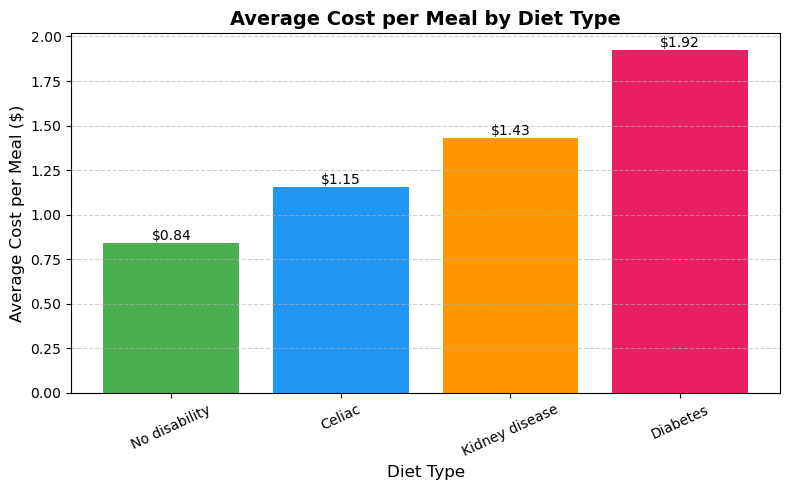

In [4]:
import matplotlib.pyplot as plt

df = results[results["success"] == True].copy()

df["cost_per_meal"] = df["cost_per_day"] / 3

avg_meal_cost = (
    df.groupby("disability")["cost_per_meal"]
    .mean()
    .sort_values()
)

colors = ["#4CAF50", "#2196F3", "#FF9800", "#E91E63"]

plt.figure(figsize=(8,5))
bars = plt.bar(avg_meal_cost.index, avg_meal_cost.values, color=colors)

plt.title("Average Cost per Meal by Diet Type", fontsize=14, weight='bold')
plt.xlabel("Diet Type", fontsize=12)
plt.ylabel("Average Cost per Meal ($)", fontsize=12)

plt.xticks(rotation=25)
plt.grid(axis='y', linestyle='--', alpha=0.6)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f"${height:.2f}",
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()